# Does segmenting into syllables remove lab signal? — figures

**Question.** At matched dimensionality, do syllables keep the individual (mouse) information of
the signal they are built from, and lose its lab information?

**Comparison.** For each channel, the syllables against the raw signal they are built from,
**per-session z-scored** (each variable z-scored by its own session's mean and SD, which is
what the paw states see before clustering). The difference is the clustering itself. The raw
block never has more dimensions than the syllables:

| channel | syllables | raw, per-session z |
|---|---|---|
| paw | paw syllables, 280 | paw speed per paw, `log(\|v\| + 1)`, 80 |
| whisk + lick | whisk / lick states, 80 | whisker motion energy (log) + lick count, 80 |
| all | the 360 LDA features | paw speed per paw + whisker ME + lick count, 160 |

All blocks use 4 epochs × 10 bins, averaged over trials.

**Metrics** (protocol of `vigor/lda/zscore_cost.py`; 260 sessions, 56 mice, 10 labs):
- *Mouse ID*: leave-one-session-out mouse identification, shrinkage LDA.
- *Mouse ID, lab-centred*: the same after centring every feature within its lab, i.e.
  individuality that is not lab.
- *Lab ID from a held-out mouse*: every session of the test mouse left out. This is lab
  signal that generalises across animals.
- *Lab η²*: mean over features of the lab share of variance.

**Uncertainty.** 95% CIs over **mice**, since sessions of one mouse are not independent. They
come from `ci_segmentation_vs_raw.py`; this notebook only reads its output.
- **Accuracies:** 2,000 bootstrap resamples of mice. The two blocks of a pair are resampled
  together, so the CI of their difference is paired.
- **Lab η²:** a leave-one-mouse-out jackknife. Resampling mice with replacement duplicates
  animals and inflates η² in every resample, which would put a percentile interval entirely
  above the estimate.

**Which syllables:** the file is set once, in `raw_vs_syllables.py` (`SYLLABLE_FILE`); the
cell below prints the one these numbers come from. The previous results (production syllables,
`8_k_10_bin_syllables_19-08-2026`) are in `archive_syllables_19-08-2026/`.

In [1]:
# ---- SHARED FIGURE STYLE ------------------------------------------------------------
import sys, pathlib, importlib

_p = pathlib.Path.cwd().resolve()
while not (_p / 'paper_style.py').exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
import paper_style
importlib.reload(paper_style)   # kernels cache modules; without this, edits stay invisible
ps = paper_style
ps.use('paper')
ROOT = str(_p) + '/'
HERE = ROOT + 'vigor/zscore/'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


In [2]:
R = pd.read_csv(HERE + 'ci_segmentation_vs_raw.csv')
print('syllables:', ', '.join(R['syllable_file'].unique()))
CHANNELS = ['paw', 'whisk + lick', 'all']
CH_LABEL = {'paw': 'Paw', 'whisk + lick': 'Whisk\n+ lick', 'all': 'All'}
METRICS = [('mouse', 'Mouse ID', 1 / 56), ('mouse_lab', 'Mouse ID,\nlab-centred', 1 / 56),
           ('lab_lomo', 'Lab ID from a\nheld-out mouse', 1 / 10), ('lab_eta2', 'Lab η²', None)]
DIFF = 'difference (syllables - raw)'
R['kind'] = np.where(R['rep'] == 'syllables', 'syllables',
                     np.where(R['rep'] == DIFF, 'difference', 'raw'))
R.pivot_table(index=['channel', 'kind'], columns='metric', values='estimate', sort=False).round(3)

syllables: 8_k_10_bin_syllables_02-10-2026


metric                   mouse  mouse_lab  lab_lomo  lab_eta2
channel      kind                                            
paw          syllables   0.728      0.644     0.215     0.127
             raw         0.783      0.679     0.446     0.228
             difference -0.055     -0.036    -0.231    -0.100
whisk + lick syllables   0.701      0.646     0.412     0.337
             raw         0.778      0.664     0.542     0.304
             difference -0.077     -0.018    -0.131     0.034
all          syllables   0.850      0.751     0.358     0.174
             raw         0.894      0.822     0.577     0.266
             difference -0.044     -0.071    -0.219    -0.092

## 1. Syllables against the matched raw signal

Two bars per channel: **syllables** (filled) and the **raw, per-session z** block it is compared
with (open). Error bars are 95% CIs over mice; dotted lines are chance.

not saved (ps.SAVE_FIGURES is False): figures/segmentation_vs_raw_bars_05-10-2026.png, figures/segmentation_vs_raw_bars_05-10-2026.svg   -- ps.saving(True) to write, or pass save=True


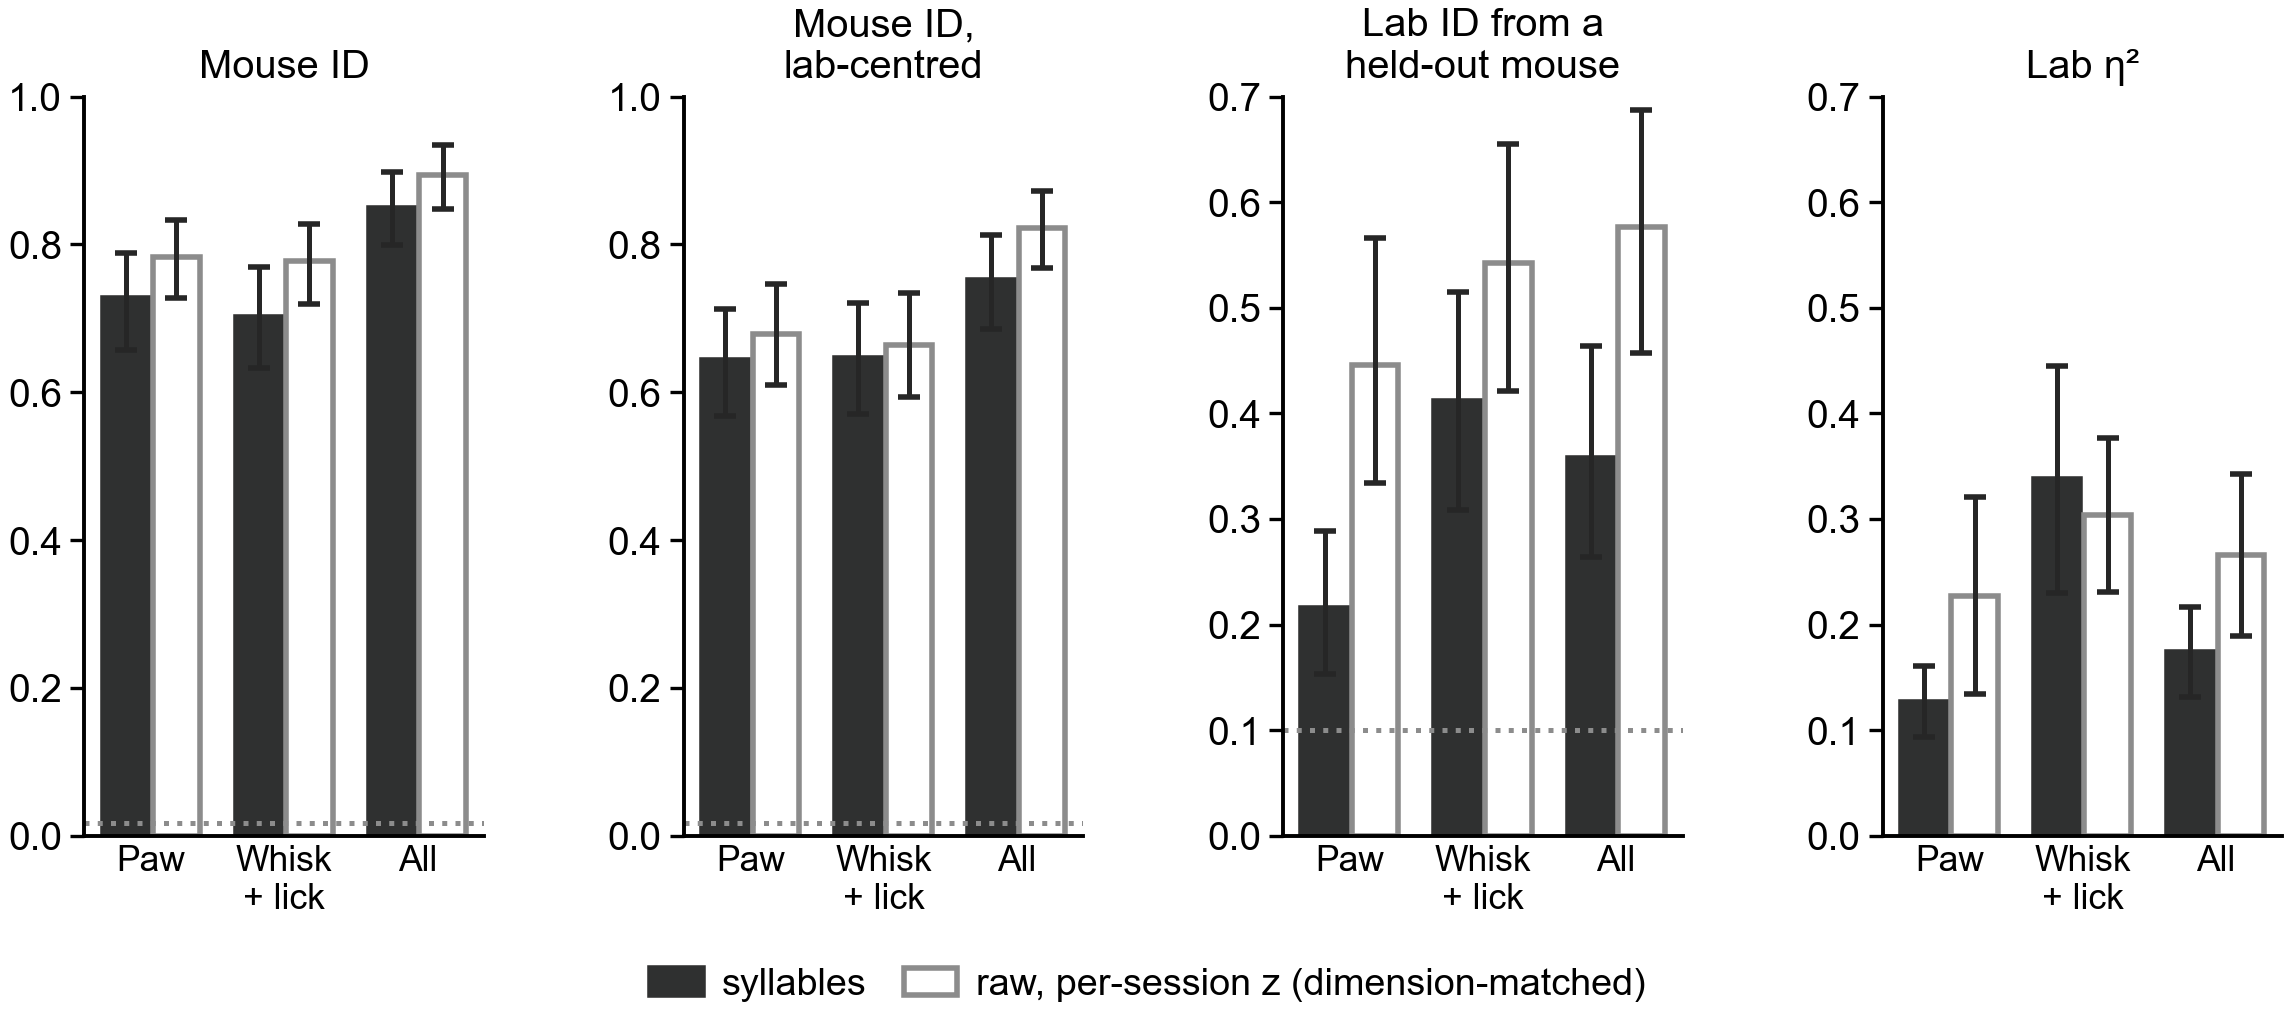

In [3]:
SYL, RAW = '#2F3030', '#8C8C8C'
fig, axes = plt.subplots(1, len(METRICS), figsize=(ps.FIG['double'][0], 2.4),
                         gridspec_kw=dict(wspace=0.5))
w = 0.38
for ax, (m, title, chance) in zip(axes, METRICS):
    for i, ch in enumerate(CHANNELS):
        for off, kind, face, edge in [(-w / 2, 'syllables', SYL, SYL), (w / 2, 'raw', 'white', RAW)]:
            r = R[(R['channel'] == ch) & (R['metric'] == m) & (R['kind'] == kind)].iloc[0]
            ax.bar(i + off, r['estimate'], width=w * 0.92, color=face, edgecolor=edge, lw=1.0)
            ax.errorbar(i + off, r['estimate'], yerr=[[r['estimate'] - r['lo']], [r['hi'] - r['estimate']]],
                        color='0.15', lw=0.9, capsize=2)
    if chance:
        ax.axhline(chance, color='0.55', ls=':', lw=0.9)
    ax.set_title(title, fontsize=plt.rcParams['font.size'] * 0.9)
    ax.set_xticks(range(len(CHANNELS)), [CH_LABEL[c] for c in CHANNELS],
                  fontsize=plt.rcParams['font.size'] * 0.8)
    ax.tick_params(axis='x', length=0)
    ax.set_ylim(0, 1.0 if m.startswith('mouse') else 0.7)
fig.legend(handles=[Patch(facecolor=SYL, edgecolor=SYL, label='syllables'),
                    Patch(facecolor='white', edgecolor=RAW, label='raw, per-session z (dimension-matched)')],
           ncol=2, loc='upper center', bbox_to_anchor=(0.5, 0.0), frameon=False,
           fontsize=plt.rcParams['font.size'] * 0.85)
ps.savefig(fig, 'segmentation_vs_raw_bars', svg=True)
plt.show()

## 2. What segmenting changes: syllables minus raw

Paired differences with 95% CIs over mice. Left of zero means the syllables have less; a CI
that excludes zero is a difference the data support.

not saved (ps.SAVE_FIGURES is False): figures/segmentation_vs_raw_differences_05-10-2026.png, figures/segmentation_vs_raw_differences_05-10-2026.svg   -- ps.saving(True) to write, or pass save=True


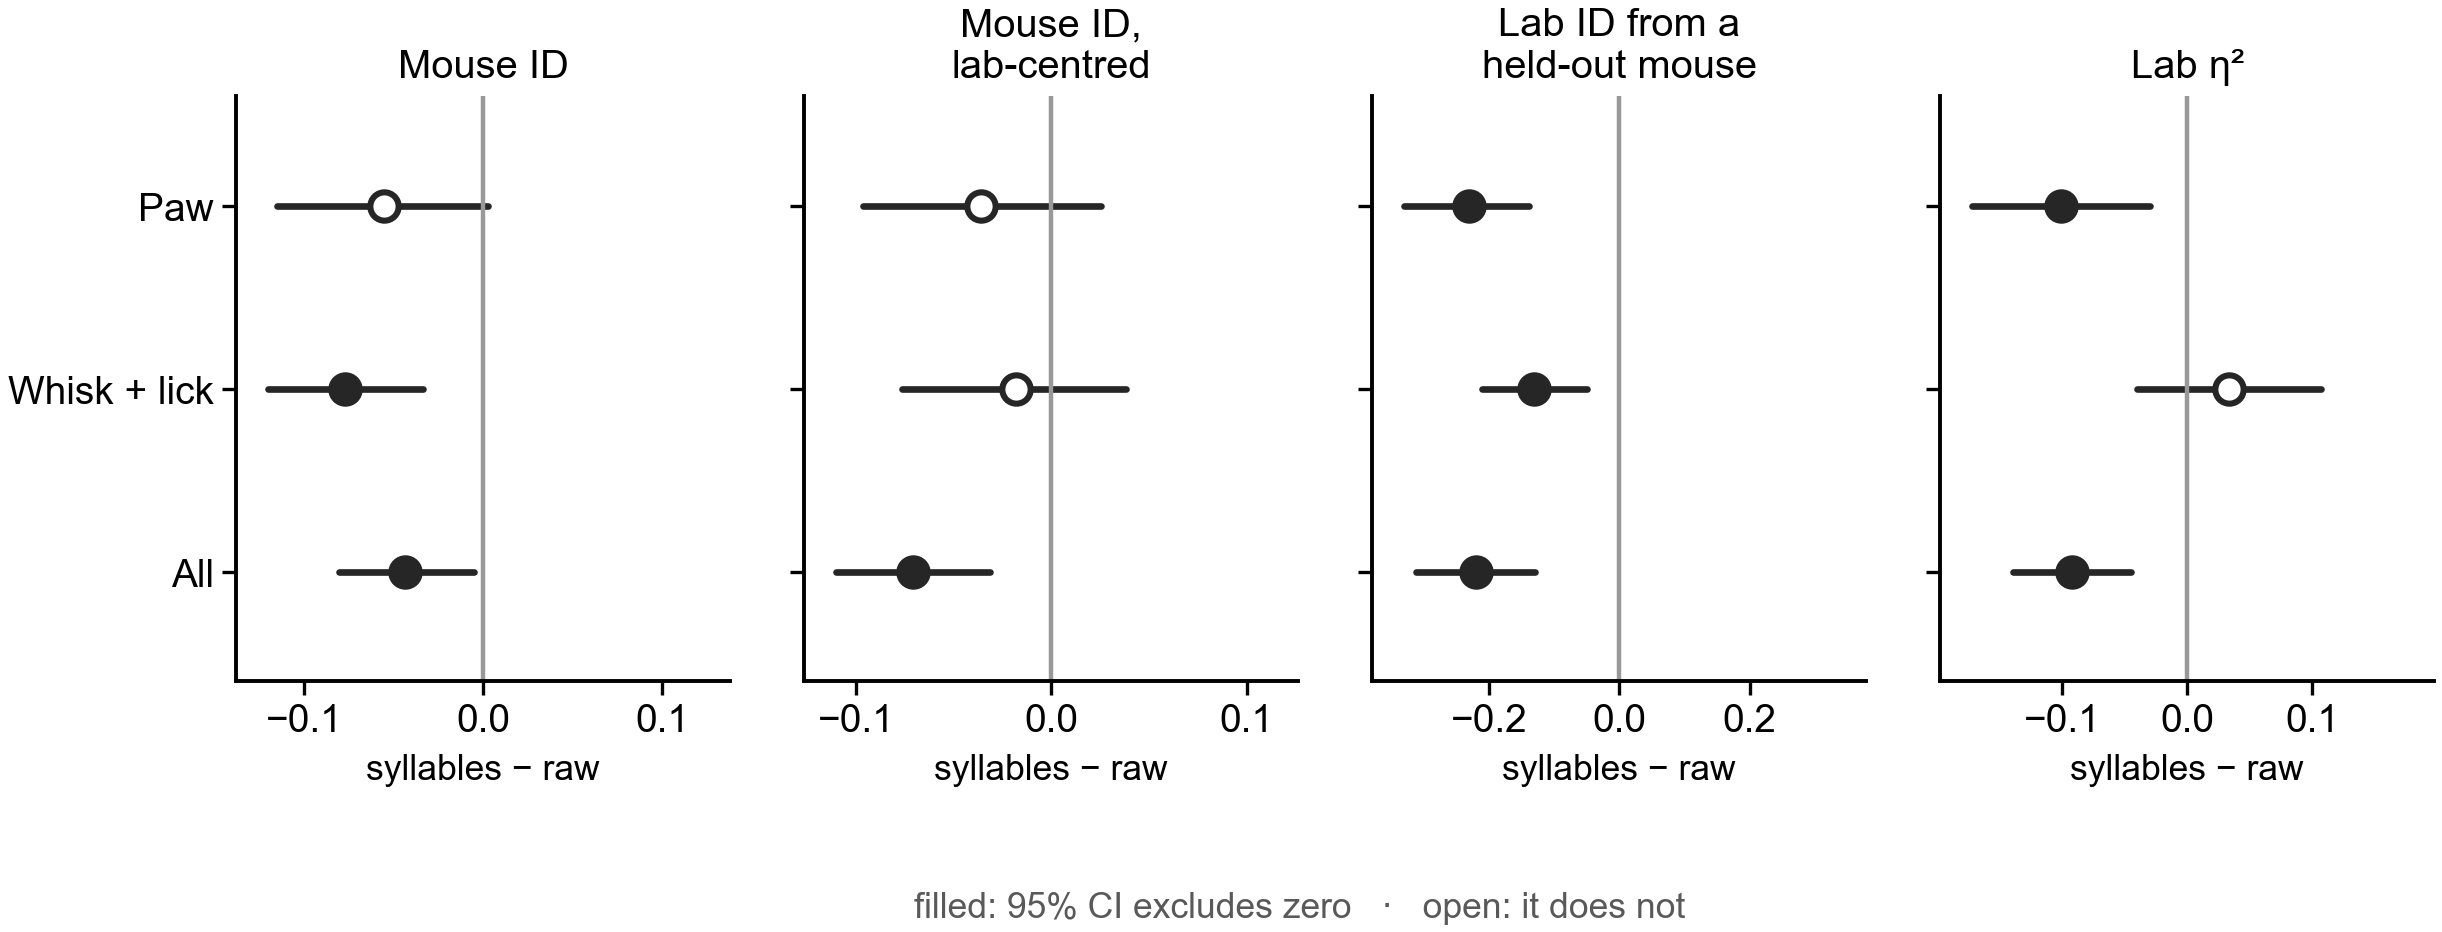

In [4]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(ps.FIG['double'][0], 1.9), sharey=True,
                         gridspec_kw=dict(wspace=0.15))
ypos = {ch: -i for i, ch in enumerate(CHANNELS)}
for ax, (m, title, _) in zip(axes, METRICS):
    for ch in CHANNELS:
        r = R[(R['channel'] == ch) & (R['metric'] == m) & (R['kind'] == 'difference')].iloc[0]
        excl = r['lo'] > 0 or r['hi'] < 0
        ax.plot([r['lo'], r['hi']], [ypos[ch]] * 2, color='0.15', lw=1.2)
        ax.scatter(r['estimate'], ypos[ch], s=26, color='0.15' if excl else 'white',
                   edgecolor='0.15', lw=1.1, zorder=3)
    ax.axvline(0, color='0.6', lw=0.8)
    ax.set_title(title, fontsize=plt.rcParams['font.size'] * 0.9)
    ax.set_xlabel('syllables − raw', fontsize=plt.rcParams['font.size'] * 0.8)
    lim = max(0.05, R[(R['metric'] == m) & (R['kind'] == 'difference')][['lo', 'hi']].abs().max().max() * 1.15)
    ax.set_xlim(-lim, lim)
axes[0].set_yticks(list(ypos.values()), [CH_LABEL[c].replace('\n', ' ') for c in CHANNELS])
axes[0].set_ylim(-len(CHANNELS) + 0.4, 0.6)
fig.text(0.5, -0.2, 'filled: 95% CI excludes zero   ·   open: it does not', ha='center',
         fontsize=plt.rcParams['font.size'] * 0.8, color='0.35')
ps.savefig(fig, 'segmentation_vs_raw_differences', svg=True)
plt.show()

## The numbers

In [5]:
T = R.assign(ci=lambda t: t.apply(lambda r: f"{r['estimate']:.3f} [{r['lo']:.3f}, {r['hi']:.3f}]", axis=1))
T.pivot_table(index=['channel', 'kind'], columns='metric', values='ci', aggfunc='first',
              sort=False)[[m for m, _, _ in METRICS]]

metric                                     mouse                mouse_lab  \
channel      kind                                                           
paw          syllables      0.728 [0.658, 0.789]     0.644 [0.569, 0.713]   
             raw            0.783 [0.727, 0.833]     0.679 [0.610, 0.747]   
             difference   -0.055 [-0.115, 0.002]   -0.036 [-0.096, 0.026]   
whisk + lick syllables      0.701 [0.632, 0.769]     0.646 [0.570, 0.720]   
             raw            0.778 [0.719, 0.828]     0.664 [0.593, 0.734]   
             difference  -0.077 [-0.120, -0.034]   -0.018 [-0.076, 0.038]   
all          syllables      0.850 [0.799, 0.898]     0.751 [0.685, 0.813]   
             raw            0.894 [0.848, 0.935]     0.822 [0.769, 0.873]   
             difference  -0.044 [-0.081, -0.005]  -0.071 [-0.110, -0.031]   

metric                                  lab_lomo                 lab_eta2  
channel      kind                                                          
paw          syllables      0.215 [0.153, 0.289]     0.127 [0.093, 0.161]  
             raw            0.446 [0.334, 0.566]     0.228 [0.135, 0.321]  
             difference  -0.231 [-0.329, -0.138]  -0.100 [-0.171, -0.029]  
whisk + lick syllables      0.412 [0.309, 0.515]     0.337 [0.230, 0.445]  
             raw            0.542 [0.421, 0.655]     0.304 [0.231, 0.377]  
             difference  -0.131 [-0.211, -0.050]    0.034 [-0.040, 0.107]  
all          syllables      0.358 [0.264, 0.464]     0.174 [0.131, 0.217]  
             raw            0.577 [0.458, 0.687]     0.266 [0.189, 0.342]  
             difference  -0.219 [-0.311, -0.129]  -0.092 [-0.139, -0.044]

## Supplementary: every raw representation (point estimates)

The other raw blocks, per-session z: speed per axis (4 per bin) and the full wavelet
spectrum (20 per bin), which has more dimensions than the syllables. These have no CIs, since they
come from `results_raw_velocity_vs_syllables.txt` / `results_raw_vs_syllables.txt`, not from
the bootstrap.

In [6]:
import re
_row = re.compile(r'^  (.+?)\s+(\d+)' + r'\s+([-\d.]+)' * 6 + r'\s*$')
COLS = ['dims', 'mouse', 'mouse_lab', 'lab_eta2', 'lab_loso', 'lab_lomo', 'icc']


def read_table(path):
    rows, section, on = [], None, False
    for line in open(path):
        if line.startswith('block'):
            on = True
            continue
        if not on or not line.strip() or line.startswith('='):
            continue
        m = _row.match(line.rstrip('\n'))
        if m:
            vals = [int(m.group(2))] + [float(v) for v in m.groups()[2:]]
            rows.append(dict(section=section, block=m.group(1).strip(), **dict(zip(COLS, vals))))
        elif not line.startswith(' '):
            section = line.strip()
    return pd.DataFrame(rows)


A = pd.concat([read_table(HERE + 'results_raw_velocity_vs_syllables.txt'),
               read_table(HERE + 'results_raw_vs_syllables.txt')], ignore_index=True)
A = A[A['block'].str.contains('session z') | A['section'].eq('SYLLABLES')]
A = A.drop_duplicates(['section', 'block'])
A[['section', 'block', 'dims', 'mouse', 'mouse_lab', 'lab_lomo', 'lab_eta2']].reset_index(drop=True)

,section,block,dims,mouse,mouse_lab,lab_lomo,lab_eta2
0,SYLLABLES,paw + whisk + lick (the 360),360,0.850,0.751,0.358,0.174
1,SYLLABLES,paw only,280,0.728,0.644,0.215,0.127
2,"RAW VELOCITY, |v| per axis (4 per bin)","paw + whisk + lick, session z",240,0.904,0.841,0.608,0.251
3,"RAW VELOCITY, |v| per axis (4 per bin)","paw only, session z",160,0.818,0.740,0.462,0.225
4,RAW SPEED PER PAW (2 per bin),"paw + whisk + lick, session z",160,0.894,0.822,0.577,0.266
5,RAW SPEED PER PAW (2 per bin),"paw only, session z",80,0.783,0.679,0.446,0.228
6,SYLLABLES,paw + whisk + lick (the 360 the LDA uses),360,0.850,0.751,0.358,0.174
7,SYLLABLES,whisk + lick only,80,0.701,0.646,0.412,0.337
8,"RAW, TIME-RESOLVED (same 4 x 10 bins, no clust...","paw + whisk + lick, session z",880,0.922,0.851,0.581,0.190
9,"RAW, TIME-RESOLVED (same 4 x 10 bins, no clust...","paw only, session z",800,0.872,0.806,0.550,0.179
